In [1]:
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
import cv2

In [2]:
# Segmentation labelling for YOLO segmentation
def label_tile_segmentation(tile_name,top,left,tile_size,rgb_path,gdf,out_dir):

# convert shapefile polygon YOLO segmentation labels for single tile

    # get geographic position of tile
    with rasterio.open(rgb_path) as ds:
        window = Window(left,top,tile_size,tile_size)
        win_transform = ds.window_transform(window)

    # create binary mask: 1 where ridge and furrow exist else 0
    mask = rasterize(
        [(geom,1) for geom in gdf.geometry],  # pair each polygon with value
        out_shape = (tile_size,tile_size),    #output mask size
        transform = win_transform,            # align polygon to correct tile position
        fill = 0,                        # no polygon = 0
        dtype ="uint8" 
    )
    # convert mask back to polygon contours for YOLO format
    contours, _ = cv2.findContours(mask , cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_SIMPLE)
    yolo_seg_labels= []
    for contour in contours:
        if len(contour)<3:
            continue
            
        # Normalise contour points to 0-1 and format as yolo segmentation labels
        norm_coords = []
        for point in contour.squeeze():
            x,y = point
            norm_coords.append(f"{x/tile_size:.6f} {y/tile_size:.6f}")  # normalization
        yolo_seg_labels.append("0 " + " ".join(norm_coords)) #  class 0 for  polygon points
    return yolo_seg_labels
        
    

In [5]:
import re
import os
pattern = re.compile(r"tile_(\d+)_(\d+)\.jpg$")

shapefile_path = "/Users/rajkamal0raon/Downloads/dataset/rnf_sites.shp"
label_out_dir = "/Users/rajkamal0raon/Desktop/dataset1/labels_for_yolo_segmentation"
jpg_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg"
tile_size = 640
rgb_path = "/Users/rajkamal0raon/Desktop/dataset1/full_site_RGB1.tif"
os.makedirs(label_out_dir,exist_ok = True)
gdf_r = gpd.read_file(shapefile_path)
gdf_r = gdf_r[gdf_r.geometry.notnull()] 

written_r = 0
for tile in os.listdir(jpg_dir):
    m = pattern.match(tile)         #extract position from filename
    if not m :
        continue
    top , left = int(m.group(1)), int(m.group(2))        # tile position
    tile_name = tile.replace(".jpg","") # remove extension for label filename

    yolo_label_seg = label_tile_segmentation(tile_name , top,left,tile_size, rgb_path,gdf_r,label_out_dir) 
    if yolo_label_seg:
        with open(os.path.join(label_out_dir, tile_name + ".txt"),"w") as f:
            f.write("\n".join(yolo_label_seg) + "\n")
        written_r +=1

print(F" segmented_label : {written_r} tiles_labelled")

 segmented_label : 1092 tiles_labelled


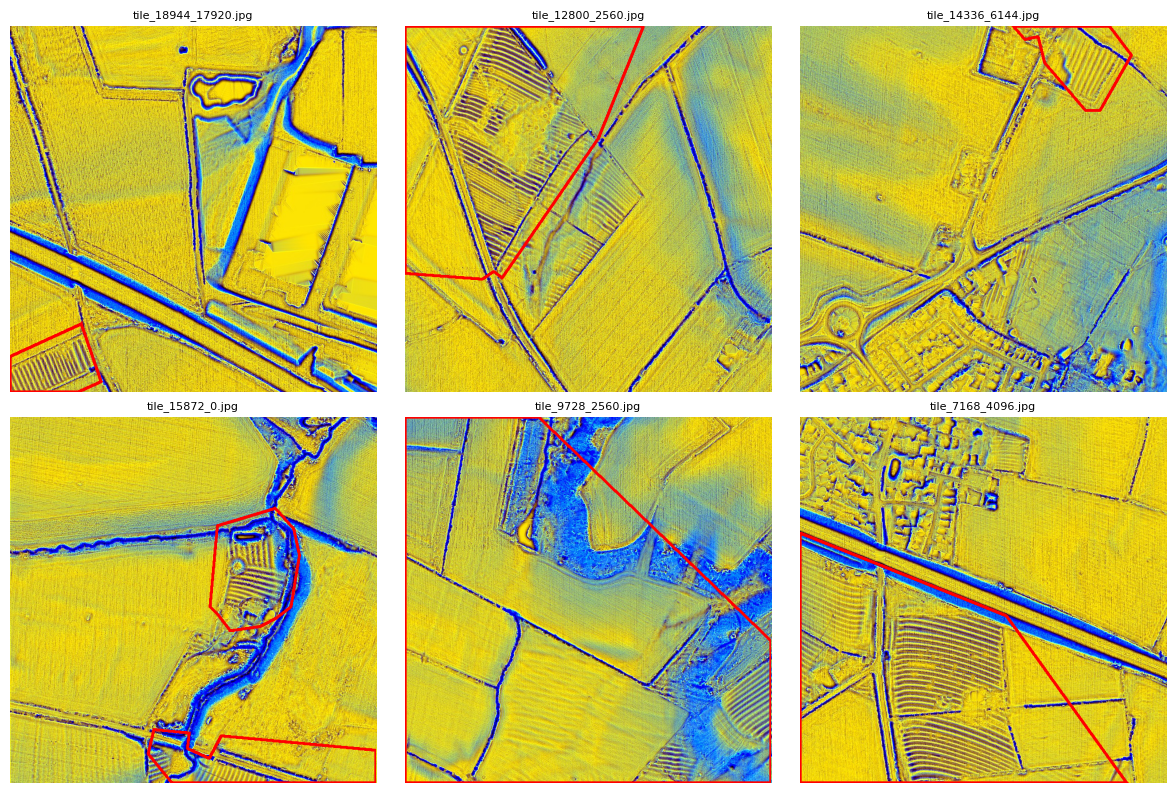

In [7]:
# segmenation labels visualisation
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import os
import random

jpg_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg"
label_dir = "/Users/rajkamal0raon/Desktop/dataset1/labels_for_yolo_segmentation"


# 4 random label files
label_files = os.listdir(label_dir)
samples = random.sample(label_files,6)

# show 6 images with segmentation polygons

fig,axes = plt.subplots(2,3,figsize = (12,8))
for ax, sample in zip(axes.flat , samples): # pairing each labels with subplots
    tile_name = sample.replace(".txt",".jpg")
    img = Image.open(os.path.join(jpg_dir,tile_name))
    ax.imshow(img)

    # draw red polygon from label file
    with open(os.path.join(label_dir , sample)) as f:
        for line in f:
            values= list(map(float, line.strip().split())) # convert labels into list of numbers
            points = [(values[i]*640 , values[i+1]*640 ) for i in range(1,len(values),2)] # # skip class id and takes point in pairs and convert to pixels
            poly = Polygon(points,linewidth = 2, edgecolor = 'red',facecolor= 'none')
            ax.add_patch(poly)

    ax.set_title(tile_name, fontsize = 8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [2]:
import shutil
shutil.make_archive(
    "/Users/rajkamal0raon/Desktop/dataset1/YOLO_segmentation_labelling_orginial_polygon",
    "zip",
    "/Users/rajkamal0raon/Desktop/dataset1/labels_for_yolo_segmentation")
print("Zipped YOLO segment labelling")
    




Zipped YOLO segment labelling
